In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)


Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Pandas version: 3.0.1
NumPy version: 2.4.2
Scikit-learn version: 1.8.0


In [2]:
import os

print(os.listdir("../data"))


['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


In [3]:
import pandas as pd

file_path = "../data/Monday-WorkingHours.pcap_ISCX.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()


Shape: (529918, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [5]:
df[" Label"].value_counts()

 Label
BENIGN    529918
Name: count, dtype: int64

In [6]:
file_path_tue = "../data/Tuesday-WorkingHours.pcap_ISCX.csv"

df_tue = pd.read_csv(file_path_tue)

df_tue.columns = df_tue.columns.str.strip()

print("Tuesday shape:", df_tue.shape)
df_tue["Label"].value_counts()

Tuesday shape: (445909, 79)


Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64

In [7]:
# Combine datasets
df_combined = pd.concat([df, df_tue], axis=0)

print("Combined shape:", df_combined.shape)
df_combined["Label"].value_counts()

Combined shape: (975827, 144)


Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64

In [8]:
# Clean Monday columns properly
df.columns = df.columns.str.strip()

# Re-merge correctly
df_combined = pd.concat([df, df_tue], axis=0)

print("Combined shape:", df_combined.shape)
df_combined["Label"].value_counts()

Combined shape: (975827, 79)


Label
BENIGN         961992
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64

In [9]:
import numpy as np

# Replace infinities with NaN
df_combined.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check missing values
missing = df_combined.isna().sum().sum()
print("Total missing values:", missing)

# Show top columns with missing values
df_combined.isna().sum().sort_values(ascending=False).head(10)

Total missing values: 1402


Flow Bytes/s                   701
Flow Packets/s                 701
Flow Duration                    0
Total Backward Packets           0
Total Length of Fwd Packets      0
Total Length of Bwd Packets      0
Destination Port                 0
Fwd Packet Length Max            0
Fwd Packet Length Min            0
Fwd Packet Length Std            0
dtype: int64

In [10]:
df_clean = df_combined.dropna()
print("After dropna shape:", df_clean.shape)

After dropna shape: (975126, 79)


In [11]:
# Separate features and label
X = df_clean.drop("Label", axis=1)
y = df_clean["Label"]

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (975126, 78)
Label shape: (975126,)


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['BENIGN' 'FTP-Patator' 'SSH-Patator']


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (780100, 78)
Test shape: (195026, 78)


In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    192260
 FTP-Patator       1.00      1.00      1.00      1587
 SSH-Patator       1.00      1.00      1.00      1179

    accuracy                           1.00    195026
   macro avg       1.00      1.00      1.00    195026
weighted avg       1.00      1.00      1.00    195026



In [16]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)

Destination Port           0.223096
Init_Win_bytes_backward    0.053984
Max Packet Length          0.046349
Packet Length Mean         0.039061
Fwd Packet Length Max      0.037219
Init_Win_bytes_forward     0.035221
Avg Fwd Segment Size       0.030329
Fwd Packet Length Std      0.029839
Packet Length Variance     0.026842
Bwd Header Length          0.026273
Packet Length Std          0.025912
Average Packet Size        0.023383
Fwd Packet Length Mean     0.021366
Subflow Bwd Bytes          0.020460
Subflow Fwd Bytes          0.020107
dtype: float64

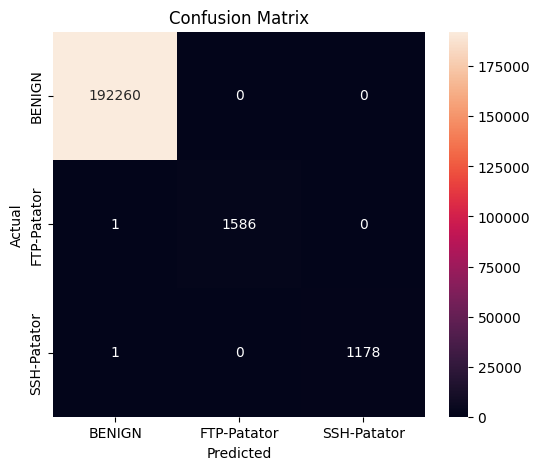

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [18]:
X_no_port = df_clean.drop(["Label", "Destination Port"], axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_port,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print(classification_report(y_test2, y_pred2, target_names=le.classes_))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    192260
 FTP-Patator       1.00      1.00      1.00      1587
 SSH-Patator       1.00      0.99      1.00      1179

    accuracy                           1.00    195026
   macro avg       1.00      1.00      1.00    195026
weighted avg       1.00      1.00      1.00    195026



In [19]:
file_path_wed = "../data/Wednesday-workingHours.pcap_ISCX.csv"

df_wed = pd.read_csv(file_path_wed)
df_wed.columns = df_wed.columns.str.strip()

print("Wednesday shape:", df_wed.shape)
df_wed["Label"].value_counts()

Wednesday shape: (692703, 79)


Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

In [20]:
# Combine all three
df_all = pd.concat([df, df_tue, df_wed], axis=0)

df_all.columns = df_all.columns.str.strip()

print("All shape:", df_all.shape)
df_all["Label"].value_counts()

All shape: (1668530, 79)


Label
BENIGN              1402023
DoS Hulk             231073
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Heartbleed               11
Name: count, dtype: int64

In [21]:
import numpy as np

df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
df_all = df_all.dropna()

print("After cleaning shape:", df_all.shape)
df_all["Label"].value_counts()

After cleaning shape: (1666532, 79)


Label
BENIGN              1400977
DoS Hulk             230124
DoS GoldenEye         10293
FTP-Patator            7935
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Heartbleed               11
Name: count, dtype: int64

In [22]:
X_all = df_all.drop("Label", axis=1)
y_all = df_all["Label"]

from sklearn.preprocessing import LabelEncoder
le_all = LabelEncoder()
y_all_encoded = le_all.fit_transform(y_all)

print("Classes:", le_all.classes_)

Classes: ['BENIGN' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest' 'DoS slowloris'
 'FTP-Patator' 'Heartbleed' 'SSH-Patator']


In [23]:
from sklearn.model_selection import train_test_split

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y_all_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_all_encoded
)

print("Train shape:", X_train_all.shape)
print("Test shape:", X_test_all.shape)

Train shape: (1333225, 78)
Test shape: (333307, 78)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model_all = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_all.fit(X_train_all, y_train_all)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
from sklearn.metrics import classification_report

y_pred_all = model_all.predict(X_test_all)

print(classification_report(
    y_test_all,
    y_pred_all,
    target_names=le_all.classes_
))

                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    280196
   DoS GoldenEye       1.00      0.99      0.99      2059
        DoS Hulk       1.00      1.00      1.00     46025
DoS Slowhttptest       0.99      0.99      0.99      1100
   DoS slowloris       1.00      0.99      1.00      1159
     FTP-Patator       1.00      1.00      1.00      1587
      Heartbleed       1.00      1.00      1.00         2
     SSH-Patator       1.00      1.00      1.00      1179

        accuracy                           1.00    333307
       macro avg       1.00      1.00      1.00    333307
    weighted avg       1.00      1.00      1.00    333307



In [26]:
import pandas as pd

df_mon = pd.read_csv("../data/Monday-WorkingHours.pcap_ISCX.csv")
df_tue = pd.read_csv("../data/Tuesday-WorkingHours.pcap_ISCX.csv")
df_wed = pd.read_csv("../data/Wednesday-workingHours.pcap_ISCX.csv")

for df in [df_mon, df_tue, df_wed]:
    df.columns = df.columns.str.strip()

df_train = pd.concat([df_mon, df_tue, df_wed])

print("Train shape:", df_train.shape)


Train shape: (1668530, 79)


In [27]:
import numpy as np

df_train.replace([np.inf, -np.inf], np.nan, inplace=True)
df_train.dropna(inplace=True)

print("After cleaning:", df_train.shape)

After cleaning: (1666532, 79)


In [28]:
df_train.memory_usage(deep=True).sum() / 1024**3

np.float64(1.0793440090492368)

In [29]:
df_thu1 = pd.read_csv("../data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
df_thu2 = pd.read_csv("../data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")

df_fri1 = pd.read_csv("../data/Friday-WorkingHours-Morning.pcap_ISCX.csv")
df_fri2 = pd.read_csv("../data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
df_fri3 = pd.read_csv("../data/Friday-WorkingHours-Afternoon-DDoS.pcap_ISCX.csv")

for df in [df_thu1, df_thu2, df_fri1, df_fri2, df_fri3]:
    df.columns = df.columns.str.strip()

df_test = pd.concat([df_thu1, df_thu2, df_fri1, df_fri2, df_fri3])

print("Test shape:", df_test.shape)

Test shape: (1162213, 79)


In [30]:
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test.dropna(inplace=True)

print("After cleaning test:", df_test.shape)

After cleaning test: (1161344, 79)


In [31]:
print("Train labels:\n", df_train["Label"].value_counts())
print("\nTest labels:\n", df_test["Label"].value_counts())

Train labels:
 Label
BENIGN              1400977
DoS Hulk             230124
DoS GoldenEye         10293
FTP-Patator            7935
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Heartbleed               11
Name: count, dtype: int64

Test labels:
 Label
BENIGN                        870343
PortScan                      158804
DDoS                          128025
Bot                             1956
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Name: count, dtype: int64


In [32]:
df_train["BinaryLabel"] = df_train["Label"].apply(
    lambda x: "BENIGN" if x == "BENIGN" else "ATTACK"
)

In [33]:
df_test["BinaryLabel"] = df_test["Label"].apply(
    lambda x: "BENIGN" if x == "BENIGN" else "ATTACK"
)

In [34]:
print(df_train["BinaryLabel"].value_counts())
print(df_test["BinaryLabel"].value_counts())

BinaryLabel
BENIGN    1400977
ATTACK     265555
Name: count, dtype: int64
BinaryLabel
BENIGN    870343
ATTACK    291001
Name: count, dtype: int64


In [35]:
X_train = df_train.drop(["Label", "BinaryLabel"], axis=1)
y_train = df_train["BinaryLabel"]

X_test = df_test.drop(["Label", "BinaryLabel"], axis=1)
y_test = df_test["BinaryLabel"]

In [36]:
from sklearn.preprocessing import LabelEncoder

le_bin = LabelEncoder()

y_train_enc = le_bin.fit_transform(y_train)
y_test_enc = le_bin.transform(y_test)

In [37]:
print(le_bin.classes_)

['ATTACK' 'BENIGN']


In [38]:
from sklearn.ensemble import RandomForestClassifier

model_bin = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model_bin.fit(X_train, y_train_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_bin = model_bin.predict(X_test)

print(classification_report(y_test_enc, y_pred_bin, target_names=le_bin.classes_))

              precision    recall  f1-score   support

      ATTACK       1.00      0.28      0.44    291001
      BENIGN       0.81      1.00      0.89    870343

    accuracy                           0.82   1161344
   macro avg       0.90      0.64      0.66   1161344
weighted avg       0.85      0.82      0.78   1161344



In [40]:
from sklearn.ensemble import RandomForestClassifier

model_bal = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model_bal.fit(X_train, y_train_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
from sklearn.metrics import classification_report

y_pred_bal = model_bal.predict(X_test)

print(classification_report(
    y_test_enc,
    y_pred_bal,
    target_names=le_bin.classes_
))

              precision    recall  f1-score   support

      ATTACK       1.00      0.23      0.37    291001
      BENIGN       0.79      1.00      0.89    870343

    accuracy                           0.81   1161344
   macro avg       0.90      0.61      0.63   1161344
weighted avg       0.85      0.81      0.76   1161344



In [42]:
"Destination Port"

'Destination Port'

In [43]:
X_train_np = X_train.drop(["Destination Port"], axis=1)
X_test_np = X_test.drop(["Destination Port"], axis=1)

In [44]:
model_no_port = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model_no_port.fit(X_train_np, y_train_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
y_pred_np = model_no_port.predict(X_test_np)

print(classification_report(
    y_test_enc,
    y_pred_np,
    target_names=le_bin.classes_
))

              precision    recall  f1-score   support

      ATTACK       0.99      0.28      0.44    291001
      BENIGN       0.81      1.00      0.89    870343

    accuracy                           0.82   1161344
   macro avg       0.90      0.64      0.67   1161344
weighted avg       0.85      0.82      0.78   1161344



In [46]:
import numpy as np
import pandas as pd

# Features only (drop labels)
X_train_full = df_train.drop(["Label", "BinaryLabel"], axis=1)
y_train_bin  = df_train["BinaryLabel"]

# Keep only BENIGN rows for anomaly training
X_train_benign = X_train_full[y_train_bin == "BENIGN"].copy()

print("X_train_full:", X_train_full.shape)
print("X_train_benign (BENIGN only):", X_train_benign.shape)

X_train_full: (1666532, 78)
X_train_benign (BENIGN only): (1400977, 78)


In [47]:
X_test_full = df_test.drop(["Label", "BinaryLabel"], axis=1)
y_test_bin  = df_test["BinaryLabel"].copy()

print("X_test_full:", X_test_full.shape)
print("y_test_bin counts:\n", y_test_bin.value_counts())

X_test_full: (1161344, 78)
y_test_bin counts:
 BinaryLabel
BENIGN    870343
ATTACK    291001
Name: count, dtype: int64


In [48]:
def check_bad(df, name):
    bad_inf = np.isinf(df.to_numpy()).sum()
    bad_nan = np.isnan(df.to_numpy()).sum()
    print(f"{name} -> inf: {bad_inf}, nan: {bad_nan}")

check_bad(X_train_benign, "X_train_benign")
check_bad(X_test_full, "X_test_full")

X_train_benign -> inf: 0, nan: 0
X_test_full -> inf: 0, nan: 0


In [49]:
import pandas as pd
import numpy as np
import sklearn
print(pd.__version__, np.__version__, sklearn.__version__)

3.0.1 2.4.2 1.8.0


In [50]:
print("df_train:", df_train.shape)
print("df_test :", df_test.shape)
print("train labels:\n", df_train["Label"].value_counts().head(10))
print("test labels:\n", df_test["Label"].value_counts().head(10))

df_train: (1666532, 80)
df_test : (1161344, 80)
train labels:
 Label
BENIGN              1400977
DoS Hulk             230124
DoS GoldenEye         10293
FTP-Patator            7935
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Heartbleed               11
Name: count, dtype: int64
test labels:
 Label
BENIGN                        870343
PortScan                      158804
DDoS                          128025
Bot                             1956
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Name: count, dtype: int64


In [51]:
df_train["BinaryLabel"] = df_train["Label"].apply(
    lambda x: "BENIGN" if x == "BENIGN" else "ATTACK"
)

df_test["BinaryLabel"] = df_test["Label"].apply(
    lambda x: "BENIGN" if x == "BENIGN" else "ATTACK"
)

print("Train binary counts:")
print(df_train["BinaryLabel"].value_counts())

print("\nTest binary counts:")
print(df_test["BinaryLabel"].value_counts())

Train binary counts:
BinaryLabel
BENIGN    1400977
ATTACK     265555
Name: count, dtype: int64

Test binary counts:
BinaryLabel
BENIGN    870343
ATTACK    291001
Name: count, dtype: int64


In [52]:
import numpy as np

# 1) Features (drop labels)
X_train_full = df_train.drop(["Label", "BinaryLabel"], axis=1)
y_train_bin  = df_train["BinaryLabel"]

X_test_full  = df_test.drop(["Label", "BinaryLabel"], axis=1)
y_test_bin   = df_test["BinaryLabel"]

# 2) Keep only BENIGN rows for anomaly training
X_train_benign = X_train_full[y_train_bin == "BENIGN"].copy()

print("X_train_full:", X_train_full.shape)
print("X_train_benign (BENIGN only):", X_train_benign.shape)
print("X_test_full:", X_test_full.shape)
print("y_test_bin counts:\n", y_test_bin.value_counts())

# 3) Safety check for NaN/Inf
def check_bad(df, name):
    arr = df.to_numpy()
    print(f"{name} -> inf: {np.isinf(arr).sum()}, nan: {np.isnan(arr).sum()}")

check_bad(X_train_benign, "X_train_benign")
check_bad(X_test_full, "X_test_full")

X_train_full: (1666532, 78)
X_train_benign (BENIGN only): (1400977, 78)
X_test_full: (1161344, 78)
y_test_bin counts:
 BinaryLabel
BENIGN    870343
ATTACK    291001
Name: count, dtype: int64
X_train_benign -> inf: 0, nan: 0
X_test_full -> inf: 0, nan: 0


In [53]:
from sklearn.preprocessing import StandardScaler

# 1) Fit scaler ONLY on benign training data
scaler = StandardScaler()
X_train_benign_scaled = scaler.fit_transform(X_train_benign)

# 2) Transform full test set using same scaler
X_test_scaled = scaler.transform(X_test_full)

print("Scaled shapes:")
print("X_train_benign_scaled:", X_train_benign_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Scaled shapes:
X_train_benign_scaled: (1400977, 78)
X_test_scaled: (1161344, 78)


In [54]:
from sklearn.ensemble import IsolationForest

# Create model
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.25,   # expected anomaly proportion (we tune later)
    random_state=42,
    n_jobs=-1
)

# Train ONLY on benign data
iso_model.fit(X_train_benign_scaled)

print("Isolation Forest trained.")

Isolation Forest trained.


In [55]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict: IsolationForest gives  1 = normal, -1 = anomaly
pred_if = iso_model.predict(X_test_scaled)

# Convert to our labels: 1 -> BENIGN, -1 -> ATTACK
y_pred_bin = np.where(pred_if == 1, "BENIGN", "ATTACK")

# Ground truth from your df_test
y_true_bin = df_test["BinaryLabel"].values

print("Confusion Matrix (rows=Actual, cols=Pred):")
print(confusion_matrix(y_true_bin, y_pred_bin, labels=["BENIGN","ATTACK"]))

print("\nReport:")
print(classification_report(y_true_bin, y_pred_bin, target_names=["BENIGN","ATTACK"]))

Confusion Matrix (rows=Actual, cols=Pred):
[[644693 225650]
 [196997  94004]]

Report:
              precision    recall  f1-score   support

      BENIGN       0.29      0.32      0.31    291001
      ATTACK       0.77      0.74      0.75    870343

    accuracy                           0.64   1161344
   macro avg       0.53      0.53      0.53   1161344
weighted avg       0.65      0.64      0.64   1161344



In [56]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.15,
    random_state=42,
    n_jobs=-1
)